In [ ]:
!pip install openpyxl
!pip install xgboost
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score

import shap

In [ ]:
uploaded = files.upload()

Saving dataset_file.csv.xlsx to dataset_file.csv.xlsx


In [ ]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

df.head()

,Country,State,Crop,Season,Year,Soil_Type,Soil_pH,Soil_Moisture_%,Nitrogen_N,Phosphorus_P,Potassium_K,Temperature_C,Rainfall_mm,Humidity_%,Wind_Speed_kmph,Irrigation_Type,Area_hectare,Yield_kg_per_ha
0,India,Gujarat,Banana,Rabi,2006,Clay,7.52,28.5,94,19,36,27.6,1119,60,3.7,Rainfed,14.81,45201.8
1,India,Tamil Nadu,Maize,Zaid,2025,Laterite,5.90,39.3,112,59,27,19.8,475,54,3.2,Canal,2.89,3287.6
2,India,Uttar Pradesh,Soybean,Kharif,2015,Red,6.53,59.0,102,74,117,34.2,727,77,4.5,Drip,5.68,1284.9
3,India,Gujarat,Chickpea,Kharif,2006,Loamy,7.77,53.0,74,67,104,28.1,435,80,19.8,Sprinkler,9.98,973.0
4,India,Bihar,Mustard,Kharif,2012,Red,6.96,50.5,76,55,80,39.3,285,81,18.1,Rainfed,11.44,1751.8


In [ ]:
le = LabelEncoder()

categorical_cols = ['Country','State','Crop','Season','Soil_Type','Irrigation_Type']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Yield_kg_per_ha', axis=1)

y = df['Yield_kg_per_ha']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_score = r2_score(y_test, rf_pred)

print("Random Forest R2 Score:", rf_score)

Random Forest R2 Score: 0.9728724789489168


In [ ]:
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_score = r2_score(y_test, xgb_pred)

print("XGBoost R2 Score:", xgb_score)

XGBoost R2 Score: 0.968510820807868


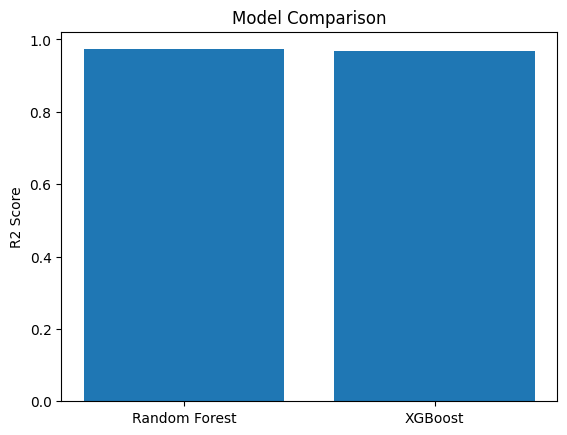

In [ ]:
models = ['Random Forest','XGBoost']

scores = [rf_score, xgb_score]

plt.bar(models, scores)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

In [ ]:
importance = xgb.feature_importances_

feature_names = df.drop('Yield_kg_per_ha', axis=1).columns

importance_df = pd.Series(importance, index=feature_names)

importance_df = importance_df.sort_values()

In [ ]:
sample = X_test[0].reshape(1,-1)

prediction = xgb.predict(sample)

print("Predicted Crop Yield:", prediction)

Predicted Crop Yield: [1943.4835]
